In [1]:
# ================== IMPORTS ==================
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision.models.segmentation import deeplabv3_resnet50
import torch.nn as nn

# ================== GOOGLE DRIVE ==================
from google.colab import drive
drive.mount('/content/drive')

# ================== PATHS ==================
model_path = "/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth"  # adjust if needed
input_folder = "/content/drive/MyDrive"  # images directly in MyDrive
output_folder = "/content/drive/MyDrive/segmentation_results"
os.makedirs(output_folder, exist_ok=True)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"❌ Model not found at: {model_path}")
else:
    print("✅ Found model:", model_path)

# ================== DEVICE ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================== MODEL ==================
num_classes = 2
model = deeplabv3_resnet50(weights=None, aux_loss=True)

# IMPORTANT: Match checkpoint architecture (Conv2d only for head)
model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)

# Load weights
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)  # strict=True is fine now
model.to(device)
model.eval()
print("✅ Model loaded successfully")

# ================== PREPROCESS ==================
def preprocess_image(img, long_side=256):
    h, w = img.shape[:2]
    scale = long_side / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img_resized = cv2.resize(img, (new_w, new_h))
    img_tensor = torch.tensor(img_resized / 255., dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    img_tensor = (img_tensor - mean) / std
    return img_tensor.to(device), (h, w)

# ================== TTA PREDICTION ==================
def tta_predict(img_tensor):
    aug_list = [
        lambda x: x,
        lambda x: torch.flip(x, [3]),
        lambda x: torch.flip(x, [2]),
        lambda x: torch.rot90(x, k=1, dims=[2, 3]),
        lambda x: torch.rot90(x, k=3, dims=[2, 3])
    ]
    outputs = []
    with torch.no_grad():
        for f in aug_list:
            t = f(img_tensor)
            out = model(t)['out']
            if f != aug_list[0]:
                if f == aug_list[1]: out = torch.flip(out, [3])
                elif f == aug_list[2]: out = torch.flip(out, [2])
                elif f == aug_list[3]: out = torch.rot90(out, k=3, dims=[2, 3])
                elif f == aug_list[4]: out = torch.rot90(out, k=1, dims=[2, 3])
            outputs.append(out)
    return torch.mean(torch.stack(outputs), dim=0)

# ================== POSTPROCESS MASK ==================
def postprocess_mask(mask_tensor, orig_size):
    mask = torch.argmax(mask_tensor, dim=1).squeeze().cpu().numpy()
    mask = cv2.resize(mask.astype(np.uint8), (orig_size[1], orig_size[0]), interpolation=cv2.INTER_NEAREST)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.dilate(mask, kernel, iterations=1)
    return mask

# ================== EXTRACT OBJECT ==================
def extract_object(img, mask):
    black_bg = np.zeros_like(img)
    black_bg[mask == 1] = img[mask == 1]
    return black_bg

# ================== RUN ON IMAGES ==================
# Optionally filter images by prefix or list
selected_prefix = "img_"   # change if needed, or set to "" to process all
# selected_files = ["car.jpg", "dog.png"]  # alternatively, specify exact files

for filename in os.listdir(input_folder):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        if selected_prefix and not filename.startswith(selected_prefix):
            continue  # skip images not matching prefix
        # if selected_files and filename not in selected_files:
        #     continue  # skip images not in list

        path = os.path.join(input_folder, filename)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_tensor, orig_size = preprocess_image(img)
        mask_tensor = tta_predict(img_tensor)
        pred_mask = postprocess_mask(mask_tensor, orig_size)

        result = extract_object(img, pred_mask)

        # Save result
        save_path = os.path.join(output_folder, filename)
        cv2.imwrite(save_path, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))

        # Also show inline
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
        plt.subplot(1, 2, 2); plt.imshow(result); plt.title("Extracted Object"); plt.axis("off")
        plt.show()

        print(f"✅ Processed & saved: {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found model: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


✅ Model loaded successfully


In [2]:
def extract_object_black_bg(img, mask):
    """
    Places the segmented object on a pure black background.
    """
    black_bg = np.zeros_like(img, dtype=np.uint8)
    black_bg[mask == 1] = img[mask == 1]
    return black_bg


In [3]:
!ls /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth

/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth


In [4]:
import os

# Root of your Drive
drive_root = "/content/drive/MyDrive"

# Walk through all folders and look for .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Show results
if pth_files:
    print("Found the following .pth files:")
    for f in pth_files:
        print(f)
else:
    print("No .pth files found in your Drive.")


Found the following .pth files:
/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth


In [ ]:
model_path = "/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)



In [6]:
import os
import torch

device = "cpu"  # or "cuda" if GPU is available
drive_root = "/content/drive/MyDrive"

# Search for .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Check if any .pth files were found
if not pth_files:
    raise FileNotFoundError("No .pth files found in your Google Drive.")

# Automatically use the first .pth file found
model_path = pth_files[0]
print(f"Loading model from: {model_path}")

# Load the model (replace 'model' with your actual model instance)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Model loaded successfully!")


Loading model from: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Model loaded successfully!


In [7]:
import os
import torch

device = "cpu"  # or "cuda" if GPU is available
drive_root = "/content/drive/MyDrive"

# Search for all .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Check if any .pth files were found
if not pth_files:
    raise FileNotFoundError("No .pth files found in your Google Drive.")

# Display all found files
print("Found the following .pth files:")
for idx, f in enumerate(pth_files):
    print(f"{idx}: {f}")

# Ask user to pick one
choice = int(input(f"Enter the number of the file to load (0-{len(pth_files)-1}): "))
model_path = pth_files[choice]

print(f"Loading model from: {model_path}")

# Load the model (replace 'model' with your actual model instance)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Model loaded successfully!")


Found the following .pth files:
0: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Enter the number of the file to load (0-0): 0
Loading model from: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Model loaded successfully!


In [8]:
import os
import torch

device = "cpu"  # or "cuda" if GPU is available
drive_root = "/content/drive/MyDrive"

# Search for .pth files
pth_files = []
for root, dirs, files in os.walk(drive_root):
    for file in files:
        if file.endswith(".pth"):
            pth_files.append(os.path.join(root, file))

# Automatically pick the file
if not pth_files:
    raise FileNotFoundError("No .pth files found in your Google Drive.")
elif len(pth_files) == 1:
    model_path = pth_files[0]
    print(f"Only one .pth file found. Loading: {model_path}")
else:
    # If multiple files exist, pick the latest modified
    model_path = max(pth_files, key=os.path.getmtime)
    print(f"Multiple .pth files found. Loading the latest: {model_path}")

# Load the model (replace 'model' with your actual model instance)
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
print("Model loaded successfully!")


Only one .pth file found. Loading: /content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth
Model loaded successfully!


In [ ]:
model.eval()  # important for inference


Saving cap.jpg to cap.jpg
Saving car.jpeg to car.jpeg
Saving car.webp to car.webp
Saving clock.jpg to clock.jpg
Saving dog.jpg to dog.jpg
Saving elephant.jpg to elephant.jpg
Saving family.jpg to family.jpg
Saving nature.jpg to nature.jpg
Saving rose.jpg to rose.jpg
Saving wall.jpg to wall.jpg


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


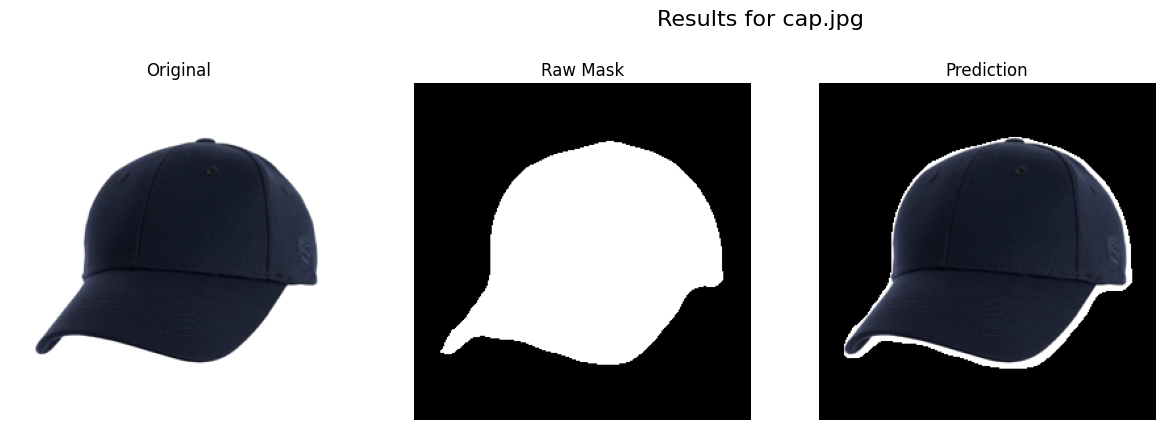

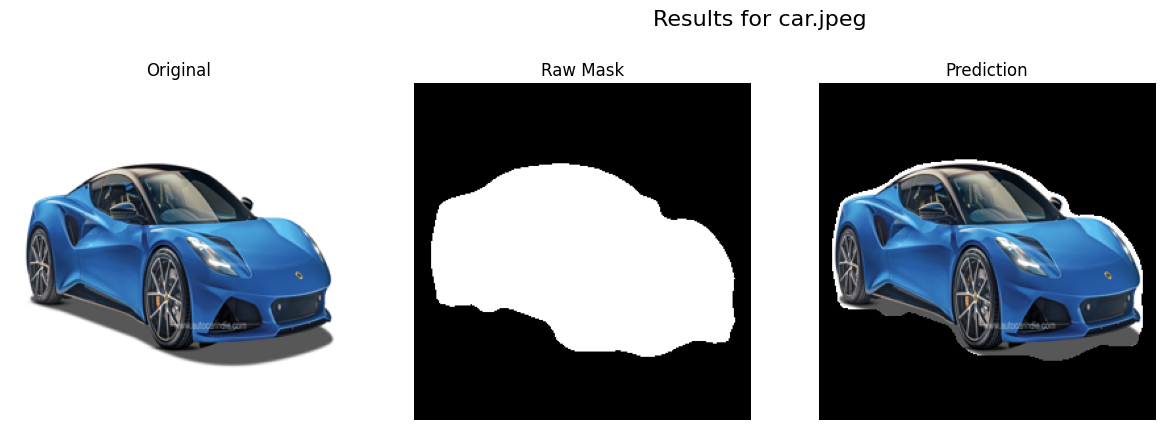

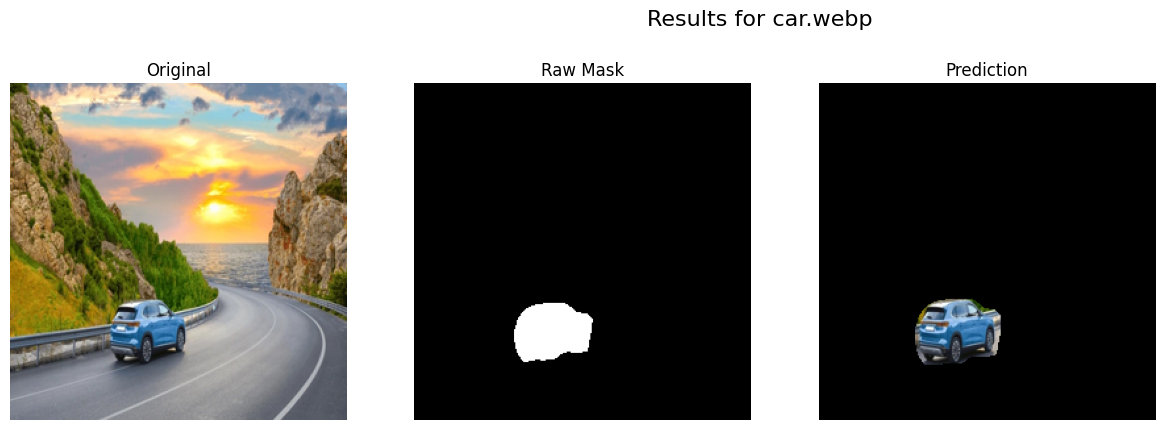

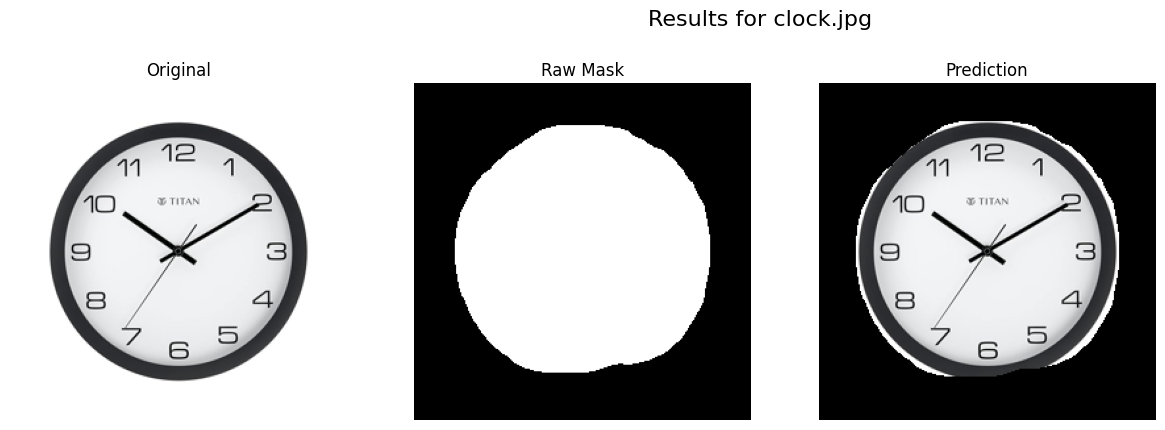

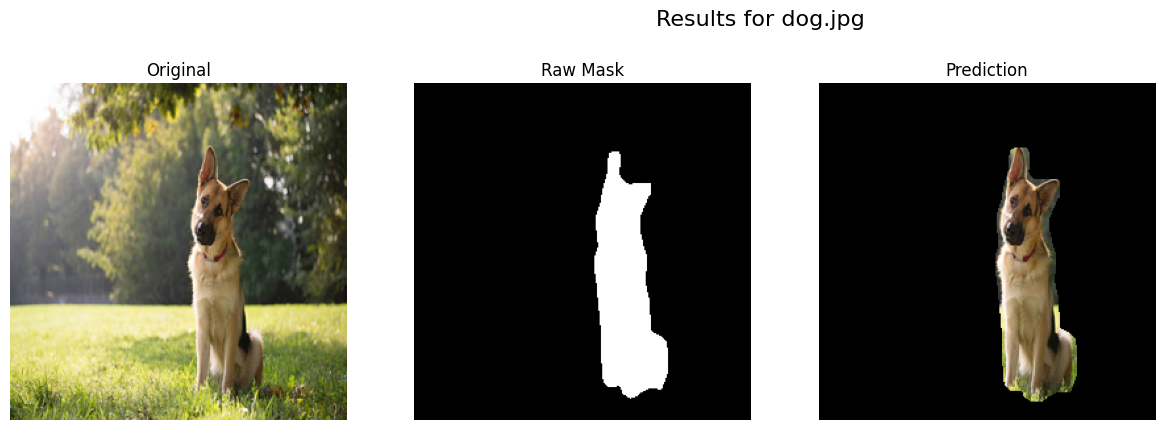

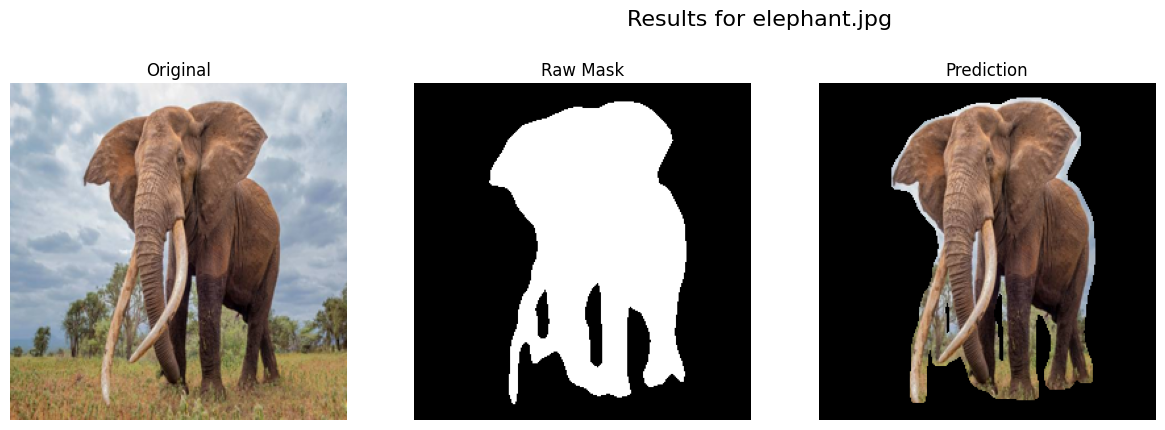

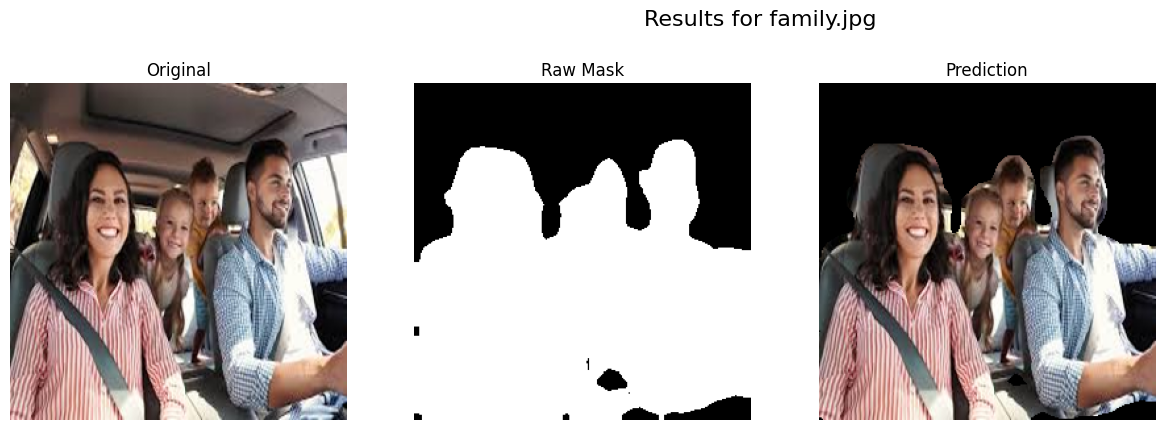

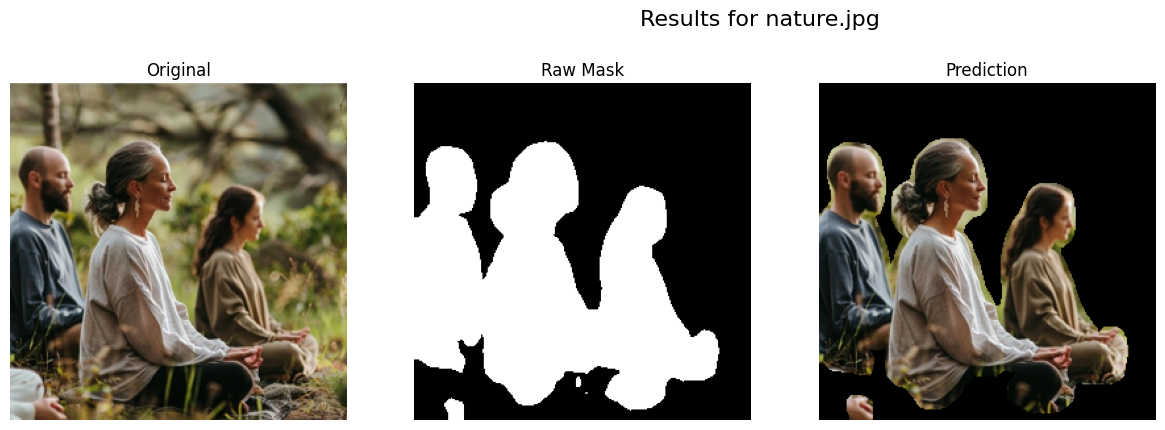

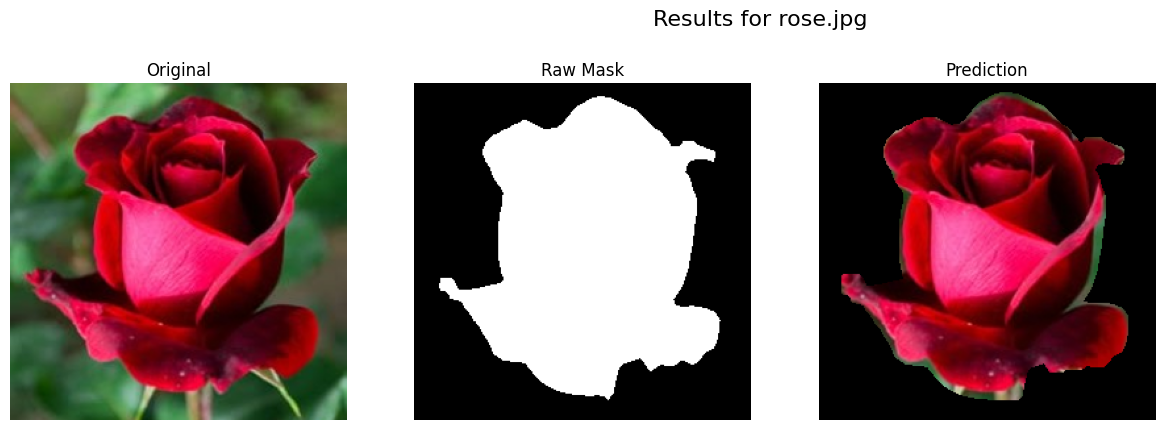

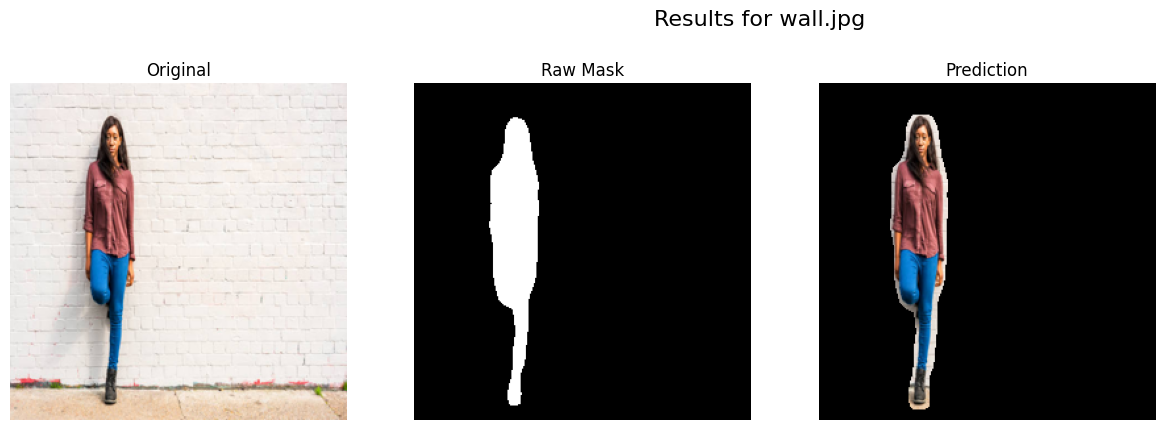

In [10]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet50
import cv2
from google.colab import files

# -------------------------------
# 1️⃣ Upload multiple images
# -------------------------------
uploaded = files.upload()  # Select multiple images by holding CTRL/SHIFT
image_paths = list(uploaded.keys())

# -------------------------------
# 2️⃣ Load trained model
# -------------------------------
model = deeplabv3_resnet50(pretrained=False, num_classes=2)
state_dict = torch.load("/content/drive/MyDrive/AI-Vision/best_deeplabv3_finetuned.pth")
model.load_state_dict(state_dict, strict=False)
model.eval()

# -------------------------------
# 3️⃣ Preprocessing function
# -------------------------------
resize_size = (256,256)  # adjust to your training size

def preprocess_image(img):
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    img_resized = img.resize(resize_size)
    return transform(img_resized).unsqueeze(0), img_resized

# -------------------------------
# 4️⃣ Mask post-processing
# -------------------------------
def clean_mask(mask):
    mask_uint8 = (mask*255).astype(np.uint8)
    kernel = np.ones((5,5), np.uint8)
    clean = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)
    clean = cv2.GaussianBlur(clean, (7,7), 0)
    return clean

# -------------------------------
# 5️⃣ Process all images
# -------------------------------
for path in image_paths:
    img = Image.open(path).convert("RGB")
    img_tensor, img_resized = preprocess_image(img)

    # Predict mask
    with torch.no_grad():
        output = model(img_tensor)['out']
        mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

    # Clean mask
    processed_mask = clean_mask(mask)

    # Extract subject
    img_array = np.array(img_resized)
    extracted = np.zeros_like(img_array)
    extracted[processed_mask>0] = img_array[processed_mask>0]
    # -------------------------------
    # 6️⃣ Visualize results
    # -------------------------------
    plt.figure(figsize=(20,5))
    plt.suptitle(f"Results for {path}", fontsize=16)

    plt.subplot(1,4,1)
    plt.imshow(img_resized)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,4,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Raw Mask")
    plt.axis('off')

    plt.subplot(1,4,3)
    plt.imshow(extracted)
    plt.title("Prediction")
    plt.axis('off')

    plt.show()
